##Mount drive to colab

In [1]:
from google.colab import drive

# The line below is likely to ask you for permission to connect colab to your
# drive. Give it access to all listed services, otherwise it will fail
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/week_1/sessions")

# Week 1 - Session 0: Dataset Sanity Check

**Purpose:** Load the dataset and explore its attributes before starting the course.


Run each cell in order to verify your setup is working.

## Create Shortcut
Make sure you've already added a shortcut to the shared data folder. If you haven't already, follow the instructions below

1. Find the path to the folder we shared with you in your "Shared with me" Tab in drive

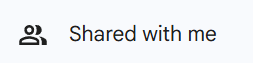

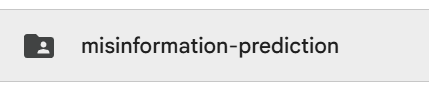

2. Right click the folder, and select Organize

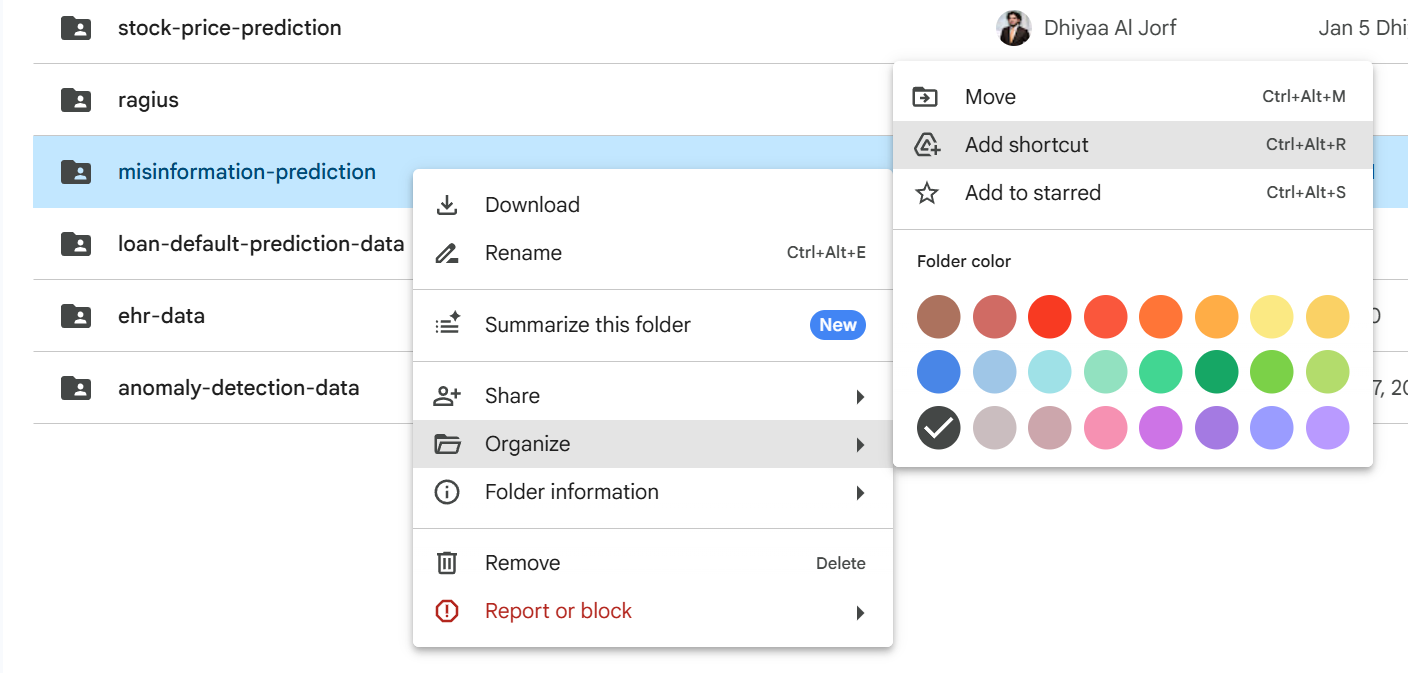

3. Find whatever location in your drive you want to store this path.

In [3]:
# Same as the path you just saved into
shortcut_path = "/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/misinformation-prediction"

In [4]:
!ls {shortcut_path}

FakeNewsNet


##Copy the data

We're going to copy the data into your own local folder. This could be in a shared folder with the rest of your team, or just your own. If it's a shared folder, you need to have editing permissions, and you need to set up a shortcut to the shared folder in your drive similar to how we did it above

In [5]:
# This path is where you store all the data for this course.
# We will set up the shortcut to it later so you won't need to worry about it.
destination_path = "/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/copied-data"

In [12]:
!cp -R {shortcut_path}/ {destination_path}

In [13]:
!ls -R {destination_path}

/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/copied-data:
FakeNewsNet

/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/copied-data/FakeNewsNet:
gossipcop.csv  politifact.csv


##Add shortcut

Finally, now we're going to add a shortcut from where you want to store your data to the expected relative path for this cloned github repo. Again, make sure you follow the steps outlined earlier. Make sure you store the shortcut at base_path/ (ask your TA if that is unclear)

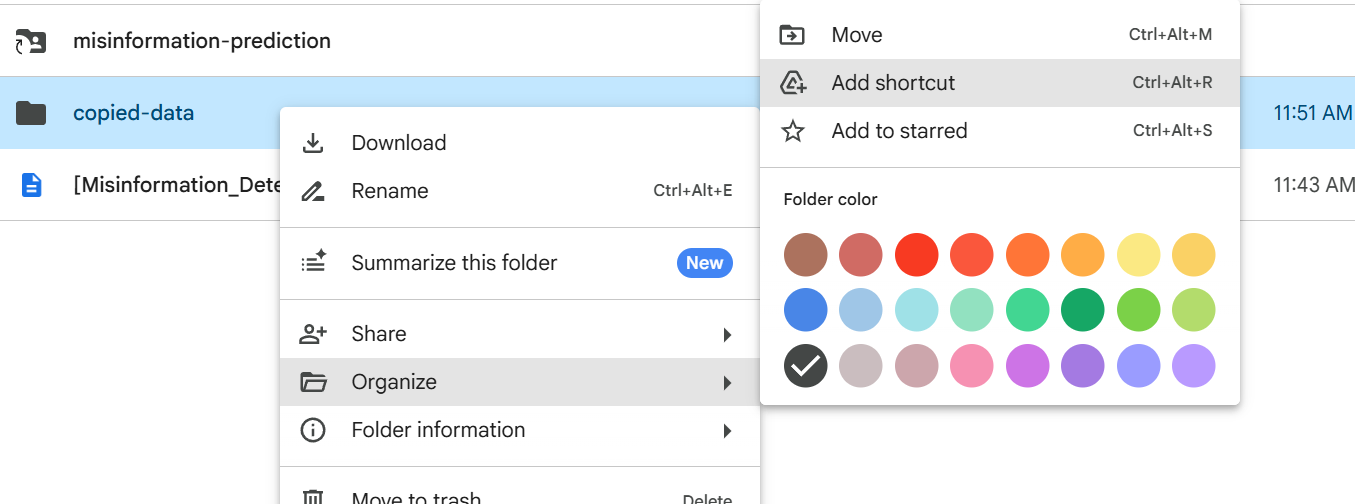

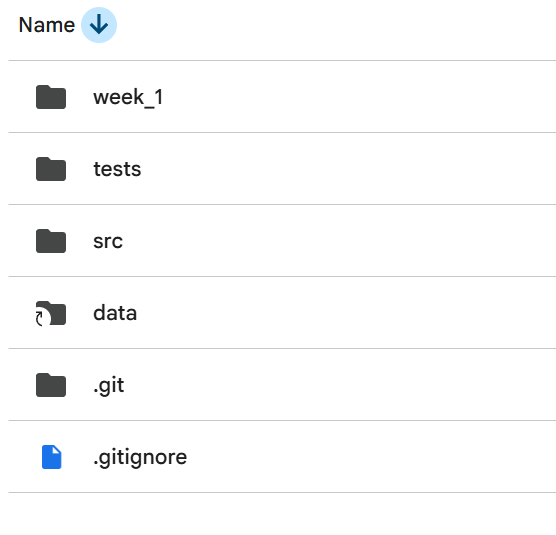

## Import Libraries

In [16]:

import pandas as pd
import os
from pathlib import Path

## Load Dataset

In [18]:
# Load FakeNewsNet CSVs
DATA_DIR = base_path / Path("../../data/raw/FakeNewsNet")
# Load and label all 4 datasets
datasets = {
    "gossipcop": pd.read_csv(DATA_DIR / Path("gossipcop.csv")),
    "politifact": pd.read_csv(DATA_DIR / Path("politifact.csv")),
}

# Add dataset_source and binary label columns
for name, df in datasets.items():
    datasets[name] = df

# Combine all into a single DataFrame
fnn_df = pd.concat(datasets.values(), ignore_index=True)

## Dataset Summary Table

In [20]:
# Basic info
print("Data Info")
fnn_df.info()


# Preview
print(f"Loaded {len(fnn_df):,} articles from GossipCop and PolitiFact")
fnn_df.sample(10)

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23672 entries, 0 to 23671
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              23672 non-null  object
 1   title           23672 non-null  object
 2   article         16428 non-null  object
 3   url             23334 non-null  object
 4   date            11498 non-null  object
 5   dataset_source  23672 non-null  object
 6   label           23672 non-null  object
dtypes: object(7)
memory usage: 1.3+ MB
Loaded 23,672 articles from GossipCop and PolitiFact


,id,title,article,url,date,dataset_source,label
3429,gossipcop-181752125,Why Katie Holmes and Jamie Foxx Never Leave a ...,Jamie Foxx and Katie Holmes have been spotted ...,people.com/movies/katie-holmes-jamie-foxx-neve...,NaN,gossipcop,fake
19391,gossipcop-891602,Saturday Savings: Emma Roberts' Nine West Slin...,NaN,https://www.storiesflow.com/article/1004483170...,NaN,gossipcop,real
9095,gossipcop-954430,Justin Theroux Slid Into the Queer Eye Guys' D...,I was a big fan of the first season and kind o...,https://www.gq.com/story/justin-theroux-how-he...,2018-07-24,gossipcop,real
1086,gossipcop-9852868069,Donald Trump Jr. Suggests Ron Perlman Knew Abo...,Donald Trump Jr. criticized Ron Perlman on soc...,www.indiewire.com/2018/06/donald-trump-jr-accu...,2018-06-26,gossipcop,1
5227,gossipcop-3869318940,Khloe Kardashian seems to have well and truly ...,Khloe Kardashian is officially not here to tak...,www.cosmopolitan.com/uk/entertainment/a2088541...,2018-05-23,gossipcop,fake
16145,gossipcop-917755,Elizabeth Chambers is Suing an Impostor Over O...,NaN,https://buzznews.co.uk/celebrities/elizabeth-c...,NaN,gossipcop,real
19543,gossipcop-946985,Supreme Court declines to hear appeal of 'Maki...,The U.S. Supreme Court declined without commen...,https://abcnews.go.com/Politics/supreme-court-...,NaN,gossipcop,real
19347,gossipcop-942377,'Sons of Anarchy' actor Alan O'Neill dies at 47,NaN,https://www.usatoday.com/story/life/people/201...,NaN,gossipcop,real
13633,gossipcop-903003,Britney Spears and boyfriend Sam Asghari celeb...,NaN,https://www.usatoday.com/story/life/entertaint...,NaN,gossipcop,real
4166,gossipcop-3282302319,Connecting People Through News,NaN,www.pressreader.com/usa/in-touch-usa/20180202/...,NaN,gossipcop,fake
